# 00 — Exploratory data analysis

Work on the **full** `Event Log.csv` (**cv + cr together**). 

Start from the raw log: case mix, missing values, `attribute_*` sparsity, and LOS — before feature engineering.

In [7]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path("..").resolve()
EVENT_LOG = ROOT / "Event Log.csv"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


SAMPLE_ROWS: int | None = None

## cv vs cr distribution

Counts **events** (rows) and **cases** (`ucid`) by `case_type`. The full CSV is streamed in chunks — do not load it into memory at once.

In [8]:
if not EVENT_LOG.exists():
    raise FileNotFoundError(f"Place Event Log.csv in {ROOT}")

event_counts: Counter[str] = Counter()
ucid_type: dict[str, str] = {}
type_mismatches = 0
rows_read = 0

chunks = pd.read_csv(
    EVENT_LOG,
    usecols=["ucid", "case_type"],
    chunksize=500_000,
    low_memory=False,
)

for chunk in chunks:
    event_counts.update(chunk["case_type"])
    for ucid, case_type in zip(chunk["ucid"], chunk["case_type"], strict=True):
        prev = ucid_type.get(ucid)
        if prev is None:
            ucid_type[ucid] = case_type
        elif prev != case_type:
            type_mismatches += 1

    rows_read += len(chunk)
    if SAMPLE_ROWS is not None and rows_read >= SAMPLE_ROWS:
        break

case_counts = Counter(ucid_type.values())

summary = pd.DataFrame(
    {
        "events": [event_counts["cv"], event_counts["cr"]],
        "cases": [case_counts["cv"], case_counts["cr"]],
    },
    index=pd.Index(["cv", "cr"], name="case_type"),
)
summary["pct_events"] = summary["events"] / summary["events"].sum() * 100
summary["pct_cases"] = summary["cases"] / summary["cases"].sum() * 100
summary["events_per_case"] = summary["events"] / summary["cases"]

print(f"rows read: {rows_read:,}" + (" (sampled)" if SAMPLE_ROWS else ""))
print(f"unique cases: {len(ucid_type):,}")
if type_mismatches:
    print(f"warning: {type_mismatches:,} ucid(s) with conflicting case_type across rows")

summary

rows read: 4,811,483
unique cases: 175,268


,events,cases,pct_events,pct_cases,events_per_case
case_type,,,,,
cv,4094131,157703,85.090834,89.978205,25.961022
cr,717352,17565,14.909166,10.021795,40.839852


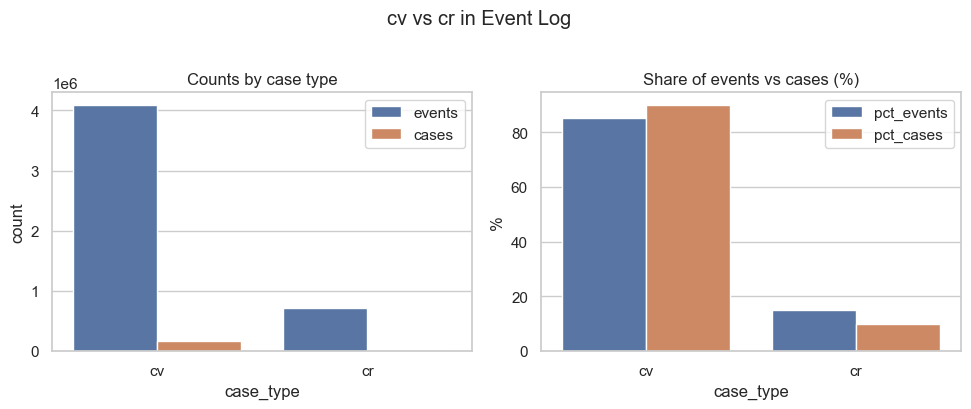

saved -> /Users/miriam.mantsurova/Desktop/University/Project/reports/figures/00_case_type_cv_cr.png


In [9]:
plot_df = summary.reset_index().melt(
    id_vars="case_type",
    value_vars=["events", "cases"],
    var_name="level",
    value_name="count",
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=plot_df, x="case_type", y="count", hue="level", ax=axes[0])
axes[0].set_title("Counts by case type")
axes[0].set_ylabel("count")
axes[0].legend(title="")

share = summary[["pct_events", "pct_cases"]].reset_index()
share_long = share.melt(id_vars="case_type", var_name="metric", value_name="pct")
sns.barplot(data=share_long, x="case_type", y="pct", hue="metric", ax=axes[1])
axes[1].set_title("Share of events vs cases (%)")
axes[1].set_ylabel("%")
axes[1].legend(title="")

fig.suptitle("cv vs cr in Event Log", y=1.02)
fig.tight_layout()
out = FIG_DIR / "00_case_type_cv_cr.png"
fig.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print(f"saved -> {out}")

## LOS (length of stay) — closed cases 

**Definition:** days from first to last `date_filed` per `ucid`, when `case_status == "closed"`. Open cases are censored.

Computed from **Event Log.csv** for **all** case types together (not split into separate cv/cr analyses).

In [11]:
from datetime import datetime


def _parse_date(s: str) -> datetime | None:
    s = (s or "").strip()
    if not s:
        return None
    try:
        return datetime.strptime(s, "%Y-%m-%d")
    except ValueError:
        return None


def compute_case_los(path: Path, *, sample_rows: int | None = None) -> pd.DataFrame:
    """One row per ucid; los_days only if case_status == closed (cv + cr)."""
    meta: dict[str, dict] = {}
    rows_read = 0

    for chunk in pd.read_csv(
        path,
        usecols=["ucid", "date_filed", "case_status", "case_type"],
        chunksize=500_000,
        low_memory=False,
    ):
        for ucid, d, status, ctype in zip(
            chunk["ucid"], chunk["date_filed"], chunk["case_status"], chunk["case_type"], strict=True
        ):
            if ucid not in meta:
                meta[ucid] = {"min": None, "max": None, "case_status": status, "case_type": ctype}
            acc = meta[ucid]
            dt = _parse_date(d)
            if dt:
                if acc["min"] is None or dt < acc["min"]:
                    acc["min"] = dt
                if acc["max"] is None or dt > acc["max"]:
                    acc["max"] = dt

        rows_read += len(chunk)
        if sample_rows is not None and rows_read >= sample_rows:
            break

    records = []
    for ucid, acc in meta.items():
        span = (acc["max"] - acc["min"]).days if acc["min"] and acc["max"] else None
        closed = acc["case_status"] == "closed"
        records.append(
            {
                "ucid": ucid,
                "case_type": acc["case_type"],
                "case_status": acc["case_status"],
                "duration_days": span,
                "los_days": span if closed else None,
            }
        )
    return pd.DataFrame(records)


cases = compute_case_los(EVENT_LOG, sample_rows=SAMPLE_ROWS)

n_cases = len(cases)
status_summary = (
    cases["case_status"]
    .value_counts()
    .rename_axis("case_status")
    .reset_index(name="n_cases")
)
status_summary["pct_cases"] = (100 * status_summary["n_cases"] / n_cases).round(2)

print(f"cases: {n_cases:,}" + (" (sampled events)" if SAMPLE_ROWS else ""))
print("case_type (all cases):\n", cases["case_type"].value_counts().to_string())
display(status_summary)

closed = cases[cases["case_status"] == "closed"]
open_cases = cases[cases["case_status"] != "closed"]
los = closed["los_days"].dropna()

print(f"\nclosed: {len(closed):,} ({100 * len(closed) / n_cases:.2f}%)")
print(f"open:   {len(open_cases):,} ({100 * len(open_cases) / n_cases:.2f}%)")
if len(open_cases):
    print(f"  median duration so far (open): {open_cases['duration_days'].median():.0f} days")

los.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

KeyboardInterrupt: 

## Case status: open vs closed

One row per `ucid` from **Event Log.csv** (cv + cr pooled). Percentages are over **all cases**.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Counts
sns.barplot(data=status_summary, x="case_status", y="n_cases", ax=axes[0], palette="muted")
axes[0].set_title("Cases by status")
axes[0].set_ylabel("number of cases")
axes[0].set_xlabel("")
for i, row in status_summary.iterrows():
    axes[0].text(
        i,
        row["n_cases"],
        f"{int(row['n_cases']):,}\n({row['pct_cases']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Percentages (pie for quick read)
axes[1].pie(
    status_summary["n_cases"],
    labels=[f"{s}\n{p:.1f}%" for s, p in zip(status_summary["case_status"], status_summary["pct_cases"])],
    autopct="",
    startangle=90,
    colors=sns.color_palette("muted", len(status_summary)),
)
axes[1].set_title("Share of all cases")

fig.suptitle(f"Open vs closed — {n_cases:,} cases (cv + cr)", y=1.02, fontsize=13)
plt.tight_layout()
out_status = FIG_DIR / "00_case_status_open_closed.png"
fig.savefig(out_status, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved -> {out_status}")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# 1 — histogram (raw days); cap x-axis at 99th pct for readability
x_cap = float(los.quantile(0.99))
sns.histplot(los[los <= x_cap], bins=50, ax=axes[0, 0])
axes[0, 0].set_title(f"LOS histogram (≤ 99th pct = {x_cap:.0f} days)")
axes[0, 0].set_xlabel("los_days")

# 2 — log1p scale (full sample)
sns.histplot(np.log1p(los), bins=50, ax=axes[0, 1])
axes[0, 1].set_title("log1p(LOS) — closed cases")
axes[0, 1].set_xlabel("log1p(los_days)")

# 3 — ECDF
sorted_los = np.sort(los.to_numpy())
ecdf_y = np.arange(1, len(sorted_los) + 1) / len(sorted_los)
axes[1, 0].plot(sorted_los, ecdf_y, linewidth=1.5)
axes[1, 0].axhline(0.5, color="gray", ls="--", lw=0.8)
axes[1, 0].axvline(los.median(), color="C1", ls="--", lw=0.8, label=f"median = {los.median():.0f}d")
axes[1, 0].set_title("ECDF of LOS")
axes[1, 0].set_xlabel("los_days")
axes[1, 0].set_ylabel("fraction of closed cases")
axes[1, 0].legend(loc="lower right")
axes[1, 0].set_xlim(0, x_cap)

# 4 — closed vs open (counts + pct; see also 00_case_status_open_closed.png)
sns.barplot(data=status_summary, x="case_status", y="n_cases", ax=axes[1, 1], palette="muted")
axes[1, 1].set_title("Case status (cv + cr)")
axes[1, 1].set_ylabel("number of cases")
for i, row in status_summary.iterrows():
    axes[1, 1].text(
        i,
        row["n_cases"],
        f"{int(row['n_cases']):,}\n({row['pct_cases']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.suptitle("LOS — closed cases (cv + cr pooled)", y=1.01)
fig.tight_layout()
out_los = FIG_DIR / "00_los_distribution.png"
fig.savefig(out_los, dpi=120, bbox_inches="tight")
plt.show()
print(f"saved -> {out_los}")

## Missing values & column sparsity 

Streams the CSV and counts **missing** vs **non-missing** per column. For boolean `attribute_*` flags, **sparsity** = share of rows where the flag is `True` (most flags are rarely true).

**Missing** = NaN, blank, or literal `Missing` / `N/A`.  

Leave `CASE_TYPE_FILTER = None` to profile **cv + cr together** (do not split by case type until further notice).

In [ ]:
MISSING_TOKENS = {"", "Missing", "missing", "NA", "N/A", "nan", "None"}
CASE_TYPE_FILTER: str | None = None  # keep None = cv + cr pooled
HEATMAP_SAMPLE_ROWS = 3_000  # rows for missingness heatmap (in-memory)


def is_missing_series(s: pd.Series) -> pd.Series:
    mask = s.isna()
    as_str = s.astype(str).str.strip()
    return mask | as_str.isin(MISSING_TOKENS)


def profile_columns_chunked(path: Path, *, sample_rows: int | None, case_type: str | None) -> pd.DataFrame:
    missing_counts: Counter[str] = Counter()
    true_counts: Counter[str] = Counter()
    rows = 0
    columns: list[str] | None = None
    attr_cols: list[str] = []

    for chunk in pd.read_csv(path, chunksize=250_000, low_memory=False):
        if case_type is not None:
            chunk = chunk[chunk["case_type"] == case_type]
            if chunk.empty:
                continue

        if columns is None:
            columns = list(chunk.columns)
            attr_cols = [
                c
                for c in columns
                if c.startswith("attribute_") and c != "attribute_duplicates"
            ]

        rows += len(chunk)
        for col in columns:
            missing_counts[col] += int(is_missing_series(chunk[col]).sum())
        for col in attr_cols:
            true_counts[col] += int((chunk[col].astype(str).str.strip() == "True").sum())

        if sample_rows is not None and rows >= sample_rows:
            break

    if not columns:
        raise ValueError("No rows read — check CASE_TYPE_FILTER  SAMPLE_ROWS")

    out = pd.DataFrame({"column": columns})
    out["n_missing"] = out["column"].map(lambda c: missing_counts[c])
    out["pct_missing"] = out["n_missing"] / rows * 100
    out["pct_non_missing"] = 100 - out["pct_missing"]
    out["is_attribute"] = out["column"].str.startswith("attribute_")
    out["pct_true"] = out["column"].map(lambda c: true_counts.get(c, np.nan) / rows * 100)
    out["n_rows"] = rows
    return out.sort_values("pct_missing", ascending=False).reset_index(drop=True)


quality = profile_columns_chunked(
    EVENT_LOG,
    sample_rows=SAMPLE_ROWS,
    case_type=CASE_TYPE_FILTER,
)
print(
    f"profiled {quality['n_rows'].iloc[0]:,} rows"
    + (f" (case_type={CASE_TYPE_FILTER})" if CASE_TYPE_FILTER else "")
    + (" — sampled" if SAMPLE_ROWS else " — full file")
)
quality.head(20)

## Feature types for modeling (categorical vs numerical vs boolean)

Classify every column for a future pipeline: **what it is**, **cardinality**, and **suggested encoding** (one-hot vs binary vs numeric scale vs embedding / target encoding).

- **Grain:** event log = one row per event; for case-level models, aggregate booleans (counts/any) and summarize categoricals per `ucid`.
- **cv + cr pooled** — `CASE_TYPE_FILTER` stays `None` unless you change policy later.
- Output: `docs/step0_feature_encoding_plan.csv`

In [ ]:
from IPython.display import display

try:
    CASE_TYPE_FILTER
except NameError:
    CASE_TYPE_FILTER = None  # cv + cr pooled

# How many rows to scan for cardinality (None = use SAMPLE_ROWS from setup, or set e.g. 500_000)
CARDINALITY_SAMPLE_ROWS: int | None = 500_000

MISSING_TOKENS_FE = {"", "Missing", "missing", "NA", "N/A", "nan", "None"}
ID_COLS = {"Unnamed: 0", "ucid"}
DATE_COLS = {"date_filed"}
JUDGE_COLS = {"District_Judge", "Magistrate_Judge", "event_judge"}
LOW_CARD_MAX = 10
MED_CARD_MAX = 50
HIGH_CARD_MAX = 500


def _is_missing(s: pd.Series) -> pd.Series:
    mask = s.isna()
    return mask | s.astype(str).str.strip().isin(MISSING_TOKENS_FE)


def _suggest_encoding(col: str, role: str, n_unique: int) -> str:
    if role == "identifier":
        return "exclude — use as group key only"
    if role == "datetime":
        return "derive time features (no one-hot)"
    if role == "boolean_flag":
        return "binary 0/1; at case level: sum / any / entropy"
    if role == "boolean":
        return "binary 0/1 (no one-hot)"
    if role == "numeric_count":
        return "numeric — scale or log1p if skewed"
    if role == "numeric":
        return "numeric — standardize / robust scale"
    # categorical
    if col in JUDGE_COLS:
        return "parse judge id → target encoding or embedding (8–32 dim)"
    if n_unique <= LOW_CARD_MAX:
        return "one-hot encoding"
    if n_unique <= MED_CARD_MAX:
        return "one-hot (watch sparsity) or target encoding"
    if n_unique <= HIGH_CARD_MAX:
        return "target encoding, feature hashing, or small embedding"
    return "embedding or aggregate to case level — avoid full one-hot"


def _complexity_tier(role: str, n_unique: int) -> str:
    if role in {"identifier", "datetime"}:
        return "structural"
    if role in {"boolean_flag", "boolean"}:
        return "low"
    if role.startswith("numeric"):
        return "low–medium"
    if n_unique <= LOW_CARD_MAX:
        return "low"
    if n_unique <= MED_CARD_MAX:
        return "medium"
    if n_unique <= HIGH_CARD_MAX:
        return "high"
    return "very high"


def profile_feature_schema(path: Path, n_rows: int) -> pd.DataFrame:
    sample = pd.read_csv(path, nrows=n_rows, low_memory=False)
    if CASE_TYPE_FILTER:
        sample = sample[sample["case_type"] == CASE_TYPE_FILTER]

    records = []
    for col in sample.columns:
        s = sample[col]
        dtype = str(s.dtype)
        n_miss = int(_is_missing(s).sum())
        n_unique = int(s.nunique(dropna=True))

        if col in ID_COLS:
            role = "identifier"
        elif col in DATE_COLS:
            role = "datetime"
        elif col.startswith("attribute_") and col != "attribute_duplicates":
            role = "boolean_flag"
        elif col == "attribute_duplicates":
            role = "numeric_count"
        elif dtype == "bool" or (col.startswith("Party_") and n_unique <= 2):
            role = "boolean"
        elif pd.api.types.is_numeric_dtype(s):
            role = "numeric"
        else:
            role = "categorical"

        records.append(
            {
                "column": col,
                "dtype": dtype,
                "role": role,
                "n_unique_sample": n_unique,
                "pct_missing_sample": round(100 * n_miss / len(sample), 2),
                "complexity": _complexity_tier(role, n_unique),
                "suggested_encoding": _suggest_encoding(col, role, n_unique),
            }
        )
    return pd.DataFrame(records)


n_scan = CARDINALITY_SAMPLE_ROWS or SAMPLE_ROWS or 500_000
feature_schema = profile_feature_schema(EVENT_LOG, n_scan)

schema_csv = ROOT / "docs" / "step0_feature_encoding_plan.csv"
schema_csv.parent.mkdir(parents=True, exist_ok=True)
feature_schema.to_csv(schema_csv, index=False)

print(f"Profiled {n_scan:,} event rows (cv + cr pooled)")
print(feature_schema["role"].value_counts().to_string())
print(f"\nSaved -> {schema_csv}")

with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(feature_schema.sort_values(["role", "column"]).reset_index(drop=True))

## High-cardinality categoricals

From `feature_schema` (event-row sample) and optional **case-level** recount on `raw_data`. High cardinality → avoid full one-hot; use target encoding, hashing, or embeddings.

In [ ]:
# Thresholds aligned with profile_feature_schema (LOW=10, MED=50, HIGH=500)
CARD_LOW, CARD_MED, CARD_HIGH = 10, 50, 500

cat_schema = feature_schema.loc[feature_schema["role"] == "categorical"].copy()
cat_schema = cat_schema.sort_values("n_unique_sample", ascending=False)

cat_schema["cardinality_band"] = pd.cut(
    cat_schema["n_unique_sample"],
    bins=[-1, CARD_LOW, CARD_MED, CARD_HIGH, np.inf],
    labels=["low (≤10)", "medium (11–50)", "high (51–500)", "very high (>500)"],
)

high_card = cat_schema[cat_schema["n_unique_sample"] > CARD_MED].reset_index(drop=True)

print(f"Categorical columns: {len(cat_schema)}")
print(f"High / very high (>{CARD_MED} uniques in sample): {len(high_card)}\n")
display(
    high_card[
        [
            "column",
            "n_unique_sample",
            "cardinality_band",
            "pct_missing_sample",
            "complexity",
            "suggested_encoding",
        ]
    ]
)

card_csv = ROOT / "docs" / "step0_high_cardinality_categoricals.csv"
card_csv.parent.mkdir(parents=True, exist_ok=True)
high_card.to_csv(card_csv, index=False)
print(f"saved -> {card_csv}")

# Case-level nunique (one row per ucid); event_judge usually lower than event-grain count
try:
    _card_base = raw_data
except NameError:
    _n = CARDINALITY_SAMPLE_ROWS if CARDINALITY_SAMPLE_ROWS else 500_000
    _card_base = pd.read_csv(EVENT_LOG, nrows=_n, low_memory=False)

cases_for_card = _card_base.drop_duplicates("ucid", keep="first")
_missing = {"", "Missing", "missing", "NA", "N/A", "nan", "None"}

case_rows = []
for col in high_card["column"]:
    if col not in cases_for_card.columns:
        continue
    s = cases_for_card[col].astype("string").str.strip()
    s = s.mask(s.isna() | s.isin(_missing))
    case_rows.append(
        {
            "column": col,
            "n_unique_event_sample": int(
                cat_schema.loc[cat_schema["column"] == col, "n_unique_sample"].iloc[0]
            ),
            "n_unique_case": int(s.nunique(dropna=True)),
        }
    )

if case_rows:
    print(f"Case-level recount: {len(cases_for_card):,} unique ucid\n")
    display(pd.DataFrame(case_rows).sort_values("n_unique_case", ascending=False))

In [ ]:
raw_data = pd.read_csv(EVENT_LOG, nrows=1000000, low_memory=False)
raw_data["Magistrate_Judge"].dropna().head(10)

## Numerical field distributions

Case-level histograms for static counts/shares (one row per `ucid`). `attribute_duplicates` is shown at **event** grain. Second figure compares **raw vs log1p** for the four count columns used in `scripts/build_features.py`.

In [ ]:
NUMERIC_ROLES = ("numeric", "numeric_count")

num_cols = feature_schema.loc[feature_schema["role"].isin(NUMERIC_ROLES), "column"].tolist()
num_cols = [c for c in num_cols if c in raw_data.columns]
if not num_cols:
    raise ValueError("No numeric columns in raw_data — run feature_schema + raw_data cells first")

cases = raw_data.drop_duplicates("ucid", keep="first")
event_only = [c for c in num_cols if c == "attribute_duplicates"]
case_cols = [c for c in num_cols if c not in event_only]

num_case = cases[case_cols].apply(pd.to_numeric, errors="coerce")
num_event = raw_data[event_only].apply(pd.to_numeric, errors="coerce") if event_only else pd.DataFrame()


def _suggest_transform(col: str, x: pd.Series) -> str:
    """Log1p only for right-skewed *counts* with a long tail — not for 0/1 shares."""
    x = x.dropna()
    if len(x) < 10:
        return "insufficient data"

    pct_zero = (x == 0).mean()
    skew = float(x.skew())
    is_share = "share" in col.lower() or (x.min() >= 0 and x.max() <= 1 and x.nunique() <= 20)
    is_integerish = np.allclose(x % 1, 0)

    if is_share:
        return "no log — bounded share; standardize or keep raw"
    if x.nunique() <= 5:
        return "discrete — no log; ordinal / one-hot if needed"
    if is_integerish and pct_zero > 0.2 and skew > 1.5 and x.quantile(0.95) > 5 * max(x.median(), 1):
        return "log1p (zero-inflated count tail)"
    if skew > 2 and x.min() >= 0 and x.quantile(0.99) > 10 * max(x.median(), 1):
        return "log1p or winsorize + scale"
    if skew > 1.5:
        return "robust scale / winsorize (log optional)"
    return "standardize (raw often OK)"


def numeric_distribution_summary(df: pd.DataFrame, *, grain: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        x = df[col].dropna()
        if x.empty:
            continue
        rows.append(
            {
                "column": col,
                "grain": grain,
                "n": len(x),
                "pct_zero": round(100 * (x == 0).mean(), 1),
                "median": round(float(x.median()), 4),
                "p95": round(float(x.quantile(0.95)), 4),
                "max": round(float(x.max()), 4),
                "skew": round(float(x.skew()), 2),
                "suggested_transform": _suggest_transform(col, x),
            }
        )
    return pd.DataFrame(rows).sort_values("skew", ascending=False, key=abs)


summary_parts = []
if len(case_cols):
    summary_parts.append(numeric_distribution_summary(num_case, grain="case"))
if len(event_only):
    summary_parts.append(numeric_distribution_summary(num_event, grain="event"))
num_summary = pd.concat(summary_parts, ignore_index=True)

summary_csv = ROOT / "docs" / "step0_numeric_distribution_summary.csv"
summary_csv.parent.mkdir(parents=True, exist_ok=True)
num_summary.to_csv(summary_csv, index=False)
display(num_summary)

# Same log1p columns as scripts/build_features.py LOG1P_COLS
LOG1P_COLS = [
    "plaintiffs_count",
    "plaintiffs_counsels_count",
    "Defendants_count",
    "Defendants_counsels_count",
]


def apply_log1p_df(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        if col in out.columns:
            x = pd.to_numeric(out[col], errors="coerce")
            out[col] = np.log1p(x.clip(lower=0))
    return out


num_case_log = apply_log1p_df(num_case, LOG1P_COLS)
num_event_log = apply_log1p_df(num_event, LOG1P_COLS) if len(event_only) else num_event

# --- Figure 1: all numerics (raw) ---
plot_frames = []
for col in case_cols:
    plot_frames.append((col, num_case[col].dropna(), "case", False))
for col in event_only:
    plot_frames.append((col, num_event[col].dropna(), "event", False))

n = len(plot_frames)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (col, series, grain, _) in zip(axes, plot_frames):
    ax.hist(series, bins=50, color="steelblue", alpha=0.85, edgecolor="white")
    ax.set_title(f"{col} ({grain}, raw)")
    ax.set_ylabel("count")

for ax in axes[len(plot_frames) :]:
    ax.set_visible(False)

fig.suptitle("Numerical fields — raw (case + event sample)", y=1.01, fontsize=13)
plt.tight_layout()
out_raw = FIG_DIR / "00_numeric_distributions_raw.png"
fig.savefig(out_raw, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved -> {out_raw}")

# --- Figure 2: log1p before/after for pipeline count columns ---
log_plot_cols = [c for c in LOG1P_COLS if c in num_case.columns]
if log_plot_cols:
    fig2, axes2 = plt.subplots(len(log_plot_cols), 2, figsize=(10, 3.2 * len(log_plot_cols)))
    if len(log_plot_cols) == 1:
        axes2 = np.array([axes2])
    for i, col in enumerate(log_plot_cols):
        x_raw = num_case[col].dropna()
        x_log = num_case_log[col].dropna()
        axes2[i, 0].hist(x_raw, bins=50, color="steelblue", alpha=0.85, edgecolor="white")
        axes2[i, 0].set_title(f"{col} — raw (skew={x_raw.skew():.1f})")
        axes2[i, 1].hist(x_log, bins=50, color="seagreen", alpha=0.85, edgecolor="white")
        axes2[i, 1].set_title(f"{col} — log1p (skew={x_log.skew():.1f})")
        if i == 0:
            axes2[i, 0].set_ylabel("count")
        axes2[i, 1].set_ylabel("count")
    fig2.suptitle("log1p transform (matches scripts/build_features.py)", y=1.01, fontsize=13)
    plt.tight_layout()
    out_log = FIG_DIR / "00_numeric_distributions_log1p.png"
    fig2.savefig(out_log, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved -> {out_log}")

print(f"summary -> {summary_csv}")

In [ ]:
MISSING_TOKENS = {"", "Missing", "missing", "NA", "N/A", "nan", "None"}

def is_missing_series(s):
    mask = s.isna()
    as_str = s.astype(str).str.strip()
    return mask | as_str.isin(MISSING_TOKENS)

cr = raw_data[raw_data["case_type"] == "cr"]
mj = cr["Magistrate_Judge"]

n = len(cr)
n_missing = is_missing_series(mj).sum()
n_present = n - n_missing

print(f"cr rows:           {n:,}")
print(f"Magistrate missing: {n_missing:,}  ({n_missing / n * 100:.2f}%)")
print(f"Magistrate present: {n_present:,}  ({n_present / n * 100:.2f}%)")

In [ ]:
from scipy.stats import chi2_contingency

MISSING_TOKENS = {"", "Missing", "missing", "NA", "N/A", "nan", "None"}


def prep_cat(s: pd.Series) -> pd.Series:
    out = s.astype("string").str.strip()
    return out.mask(out.isna() | out.isin(MISSING_TOKENS), "__missing__")


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    table = pd.crosstab(x, y)
    if table.size == 0 or min(table.shape) < 2:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return float(np.sqrt(chi2 / (n * min(r - 1, k - 1))))


def categorical_association_matrix(df: pd.DataFrame) -> pd.DataFrame:
    cols = [c for c in df.columns if df[c].nunique(dropna=False) > 1]
    mat = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols, dtype=float)
    for i, c1 in enumerate(cols):
        for c2 in cols[i + 1 :]:
            v = cramers_v(df[c1], df[c2])
            mat.loc[c1, c2] = mat.loc[c2, c1] = v
    return mat


# EDA only — keep all categorical columns; drops/bool conversion live in scripts/build_features.py
cat_cols = feature_schema.loc[feature_schema["role"] == "categorical", "column"].tolist()
cat_cols = [c for c in cat_cols if c in raw_data.columns]

# one row per case: dedupe on ucid first, then take categorical columns
cases = raw_data.drop_duplicates("ucid", keep="first")
cat_df = cases[cat_cols].apply(prep_cat)

# optional: criminal only
# cat_df = raw_data.loc[raw_data["case_type"] == "cr"].drop_duplicates("ucid", keep="first")[cat_cols].apply(prep_cat)

assoc = categorical_association_matrix(cat_df)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    assoc,
    vmin=0,
    vmax=1,
    cmap="rocket_r",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Cramér's V"},
    ax=ax,
)
ax.set_title("Categorical × categorical association (case level)")
plt.tight_layout()

out = FIG_DIR / "00_categorical_cramers_v.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved -> {out}")